### V4, will be adding washout to see if that helps the scaling issue.


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np      
from scipy.integrate import complex_ode

from tasks import make_static_sin_task
from encoding_masking import build_masked_input, compute_tdm_params
from Reservoirs.ELM_static import run_elm_static, ELMStaticParams
from readout import split_states_targets, fit_ridge_readout, predict_readout
from metrics import mse, nrmse
from Reservoirs.LangKobayashi import expand_virtual_nodes, simulate_lk, simulate_lk_mini, extract_R_from_E, intensities_after_theta_times, charge_at_theta_intervals 

In [2]:
'''
L = 1000
N = 20

#reservoir parameters:
p = 0.05 #normalised injection current
eta = 0.01 #input strength 
alpha = 0 #linewidth enhancemenet factor
phi = 0.0 #phase shift
TLk = 50
kappa = 0.1 
D_noise = 10**-7*0

xi = 0 #for now, this is time dependant and represents Gaussian noise.

task_seed = 0
mask_seed = 42


#g = 1.0
ridge_alpha = 0
split = 0.8

theta = 22
dt = 0.1
tau_factor = 1.41 #as per the Kathy Ludge paper.

TDM_parameters = compute_tdm_params(N, theta, dt, tau_factor)

tap_stride = TDM_parameters.tap_stride
Nd_loop = TDM_parameters.Nd_loop
print(TDM_parameters)
'''

'\nL = 1000\nN = 20\n\n#reservoir parameters:\np = 0.05 #normalised injection current\neta = 0.01 #input strength \nalpha = 0 #linewidth enhancemenet factor\nphi = 0.0 #phase shift\nTLk = 50\nkappa = 0.1 \nD_noise = 10**-7*0\n\nxi = 0 #for now, this is time dependant and represents Gaussian noise.\n\ntask_seed = 0\nmask_seed = 42\n\n\n#g = 1.0\nridge_alpha = 0\nsplit = 0.8\n\ntheta = 22\ndt = 0.1\ntau_factor = 1.41 #as per the Kathy Ludge paper.\n\nTDM_parameters = compute_tdm_params(N, theta, dt, tau_factor)\n\ntap_stride = TDM_parameters.tap_stride\nNd_loop = TDM_parameters.Nd_loop\nprint(TDM_parameters)\n'

In [3]:
'''
L = 1000
N = 20

#reservoir parameters:
p = 0.05 #normalised injection current/pump rate
eta = 0.01 #input strength 
alpha = 0 #linewidth enhancemenet factor
phi = 0.0 #phase shift
TLk = 10
kappa = 0.1
D_noise = 10**-7*0

xi = 0 #for now, this is time dependant and represents Gaussian noise.

task_seed = 0
mask_seed = 42


#g = 1.0
ridge_alpha = 1e-3*0
split = 0.8

theta = 22
dt = 0.1
tau_factor = 1.41 #as per the Kathy Ludge paper.

TDM_parameters = compute_tdm_params(N, theta, dt, tau_factor)

tap_stride = TDM_parameters.tap_stride
Nd_loop = TDM_parameters.Nd_loop
print(TDM_parameters)
'''

'\nL = 1000\nN = 20\n\n#reservoir parameters:\np = 0.05 #normalised injection current/pump rate\neta = 0.01 #input strength \nalpha = 0 #linewidth enhancemenet factor\nphi = 0.0 #phase shift\nTLk = 10\nkappa = 0.1\nD_noise = 10**-7*0\n\nxi = 0 #for now, this is time dependant and represents Gaussian noise.\n\ntask_seed = 0\nmask_seed = 42\n\n\n#g = 1.0\nridge_alpha = 1e-3*0\nsplit = 0.8\n\ntheta = 22\ndt = 0.1\ntau_factor = 1.41 #as per the Kathy Ludge paper.\n\nTDM_parameters = compute_tdm_params(N, theta, dt, tau_factor)\n\ntap_stride = TDM_parameters.tap_stride\nNd_loop = TDM_parameters.Nd_loop\nprint(TDM_parameters)\n'

In [4]:
#commonly tuned paramameters
L = 1030
N = 20
eta = 0.01 #input strength
TLk = 10
kappa = 0.0 #feedback 
ridge_alpha = 1e-4*0
washout = 30


#reservoir parameters:
p = 0.05 #normalised injection current/pump rate
alpha = 0 #linewidth enhancemenet factor
phi = 0 #phase shift
D_noise = 10**-7*0

task_seed = 0
mask_seed = 42


#g = 1.0
split = 0.8

theta = 22
dt = 0.1
tau_factor = 1.41 #as per the Kathy Ludge paper.

TDM_parameters = compute_tdm_params(N, theta, dt, tau_factor)

tap_stride = TDM_parameters.tap_stride
Nd_loop = TDM_parameters.Nd_loop
print(TDM_parameters)

TDMParams(N=20, theta=22, dt=0.1, T=440, tau=620.4, Nd_loop=4400, Nd_delay=6204, tap_stride=220)


In [5]:
#task = make_static_sin_task(L=L, seed=task_seed)
#x, y = task.x, task.y
x = np.linspace(-1., 1., L)
y = np.sin(2.0 * np.pi * x)



In [6]:
x_norm, mask, V = build_masked_input(x, N=N, rng=mask_seed) 

In [7]:
tap_stride = TDM_parameters.tap_stride  
Nd_delay = TDM_parameters.Nd_delay    
tau = TDM_parameters.tau


Vs = expand_virtual_nodes(V, tap_stride=tap_stride, Nd=Nd_loop)  
E_hist, n_hist = simulate_lk(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, D_noise=D_noise, Tlk=TLk, E0=1e-3+0j, n0=0.0)
#
#print("R shape:", R.shape)  # should be (L, N)




In [8]:
R = extract_R_from_E(E_hist, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop, washout_cycles=washout)

In [9]:
y = y[washout:]

In [10]:
s = split_states_targets(R, y, split=split)
#model = fit_ridge_readout(s.R_train, s.y_train, alpha=ridge_alpha, fit_intercept=False)
model = fit_ridge_readout(s.R_train, s.y_train, alpha= alpha, fit_intercept=True) # trying this to see if fit intercpet true improves performance
y_pred = predict_readout(model, s.R_test)

MSE: 0.0007416494934753538
NRMSE: 0.0964662012208559


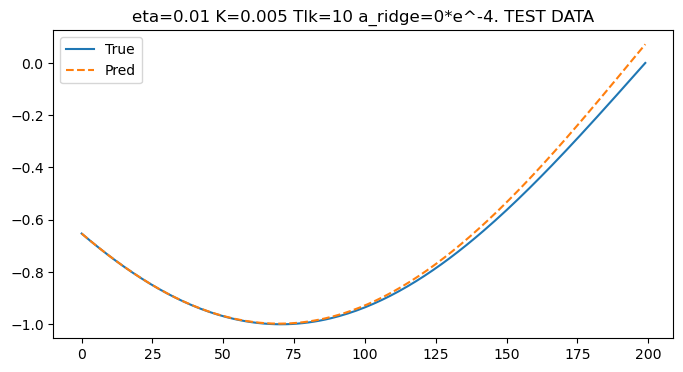

In [11]:
print("MSE:", mse(s.y_test, y_pred))
print("NRMSE:", nrmse(s.y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(s.y_test, label="True")
plt.plot(y_pred, "--", label="Pred")
plt.title("eta=0.01 K=0.005 Tlk=10 a_ridge=0*e^-4. TEST DATA")
plt.legend()
plt.show()

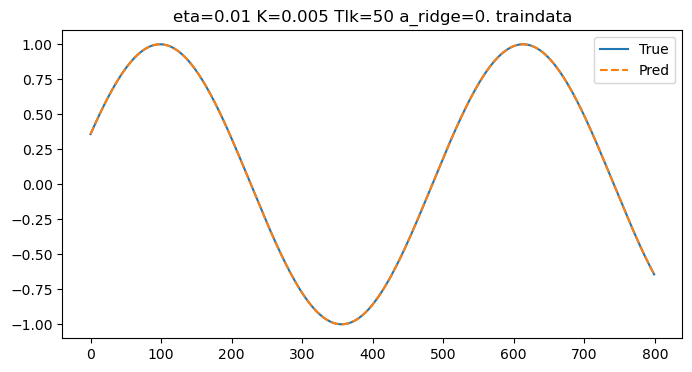

In [12]:
y_pred_train = predict_readout(model, s.R_train)

plt.figure(figsize=(8,4))
plt.plot(s.y_train, label="True")
plt.plot(y_pred_train, "--", label="Pred")
plt.title("eta=0.01 K=0.005 Tlk=50 a_ridge=0. traindata")
plt.legend()
plt.show()

In [13]:
#N_of_thetas = 70*5
N_of_thetas = 2000
E_hist1, n_hist1 = simulate_lk_mini(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=0, D_noise=D_noise, Tlk=TLk, E0=1e-3+0j, n0=0.0, N_of_thetas=N_of_thetas, tap_stride=tap_stride)
#eta = 0 above on this as to see the effects of the laser without inputs being pumped in.
number_of_points = N_of_thetas*tap_stride
#R_mini = extract_R_from_E(E_hist1, L=L, N=, tap_stride=tap_stride, Nd_loop=Nd_loop)
#print("R shape:", R_mini.shape)  # should be (L, N)

R_mini_array = intensities_after_theta_times(E_hist1, N_of_thetas=N_of_thetas, tap_stride=tap_stride, Nd_loop=Nd_loop, washout_cycles=0)
print("R_mini shape:", R_mini_array.shape)


R_mini shape: (2000,)


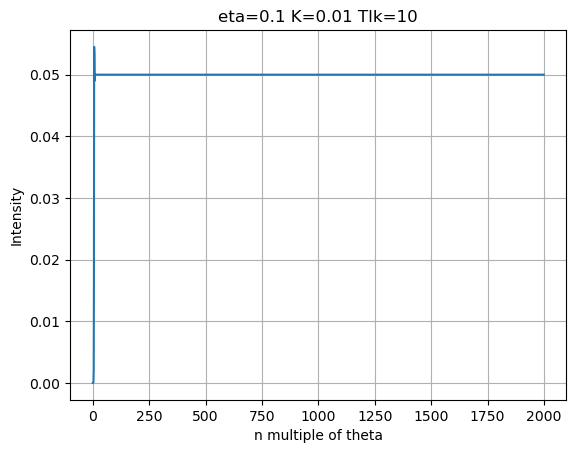

In [14]:
plt.plot(R_mini_array)
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.1 K=0.01 Tlk=10")
plt.grid(True)
plt.show()

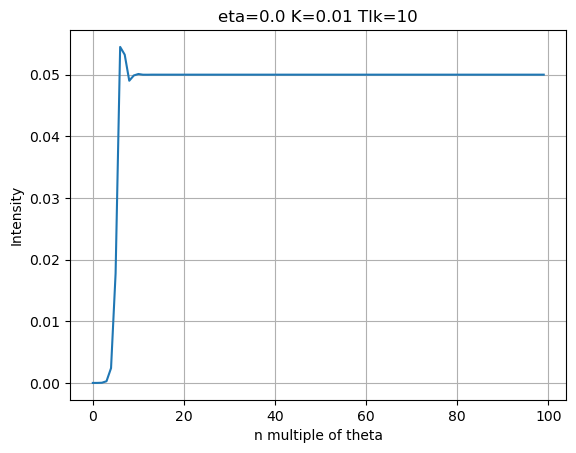

In [15]:
plt.plot(R_mini_array[0:100])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.0 K=0.01 Tlk=10")
plt.grid(True)
plt.show()

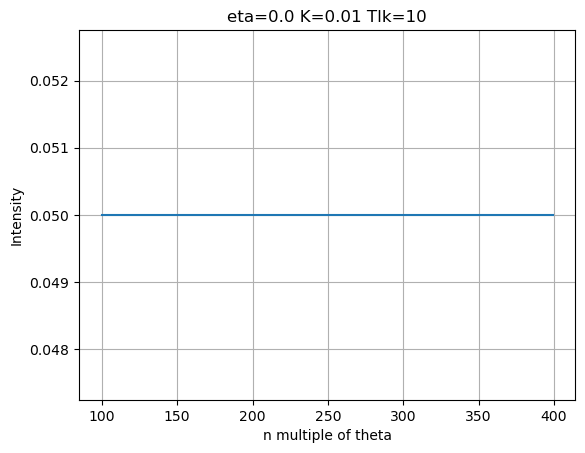

In [16]:
plt.plot(np.arange(100, 400),R_mini_array[100:400])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.0 K=0.01 Tlk=10")
plt.grid(True)
plt.show()

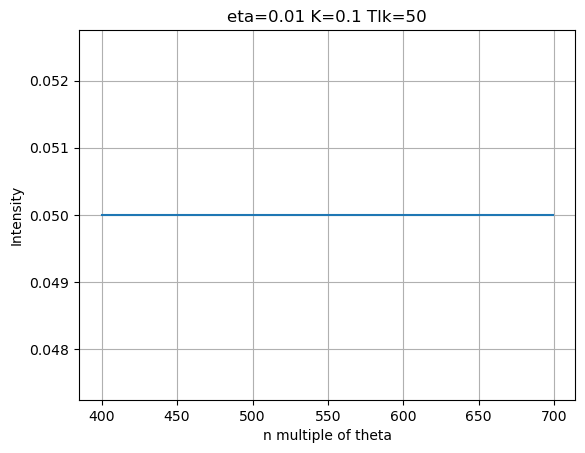

In [17]:
plt.plot(np.arange(400, 700),R_mini_array[400:700])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.01 K=0.1 Tlk=50")
plt.grid(True)
plt.show()

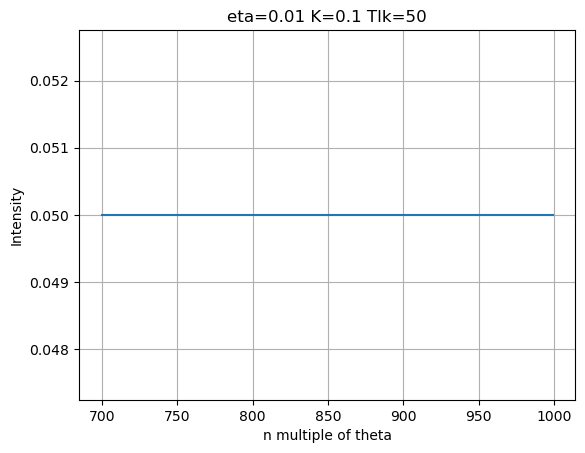

In [18]:
plt.plot(np.arange(700, 1000),R_mini_array[700:1000])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.01 K=0.1 Tlk=50")
plt.grid(True)
plt.show()

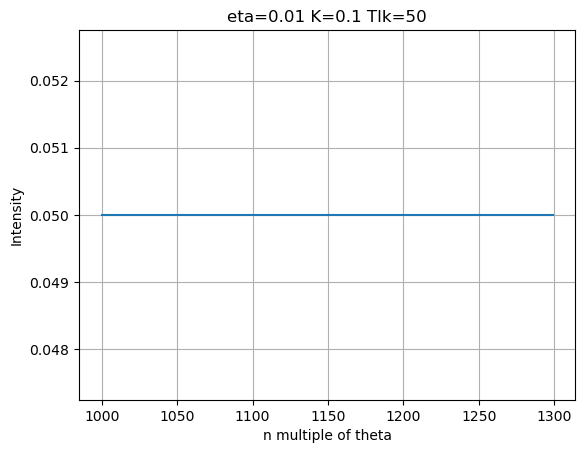

In [19]:
plt.plot(np.arange(1000, 1300),R_mini_array[1000:1300])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.01 K=0.1 Tlk=50")
plt.grid(True)
plt.show()

In [20]:
nt_at_theta_intervals = charge_at_theta_intervals(n_hist1, N_of_thetas=N_of_thetas, tap_stride=tap_stride, Nd_loop=Nd_loop, washout_cycles=30)

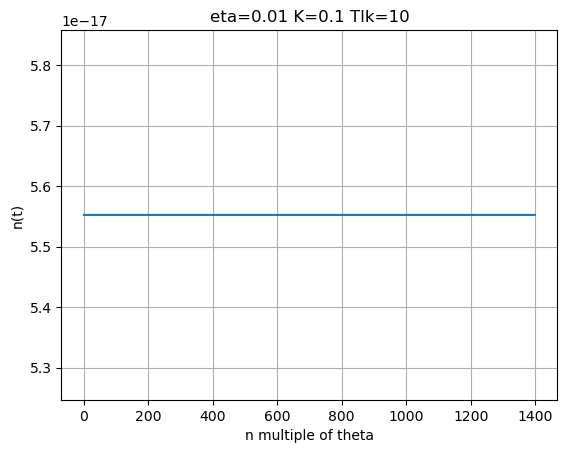

In [21]:
plt.plot(nt_at_theta_intervals)
plt.xlabel("n multiple of theta")
plt.ylabel("n(t)")
plt.title("eta=0.01 K=0.1 Tlk=10")
plt.grid(True)
plt.show()